# LOGIVISION — Train YOLOv8 on Google Colab (T4)

**Purpose.** Fine-tune YOLOv8n on the Kaggle warehouse-delivery-box
dataset using a free Colab T4 GPU. 50 epochs at 640 px takes **~25
minutes on T4**, vs ~4 hours on an M3 CPU.

## Before you run

1. *Runtime → Change runtime type → T4 GPU* (confirm top-right).
2. Have your Kaggle API key handy
   (https://www.kaggle.com/settings/account → "Create New Token").
3. Add the key to Colab Secrets:
   *Colab left sidebar → key icon → add secret*
   - `KAGGLE_USERNAME` = your Kaggle username
   - `KAGGLE_KEY` = the long hex string in the downloaded `kaggle.json`
   - Toggle **Notebook access** ON for both.

## What this notebook does

| Cell | Step | Time on T4 |
|---|---|---|
| 1 | Detect Colab; clone repo (depth=1) | 5 s |
| 2 | Install ultralytics, kagglehub, pyyaml | 30 s |
| 3 | Set Kaggle creds from Colab Secrets | <1 s |
| 4 | Download Kaggle dataset (~860 MB) | 1-3 min |
| 5 | Convert OBB labels → AABB (uses `scripts/prepare_kaggle_warehouse.py`) | 10 s |
| 6 | Train YOLOv8n: 50 epochs, imgsz=640, batch=32, AdamW, cos_lr | **~25 min** |
| 7 | Validate on the held-out test split | 30 s |
| 8 | Plot training curves | 5 s |
| 9 | Download `best.pt` + `results.csv` to your machine | 5 s |

At the end you drop the downloaded files into your local repo and
register the model in MLflow with `make register-from-colab`.

In [4]:
# 1. Detect Colab and clone the repo (shallow).
import os, sys, subprocess, pathlib

IN_COLAB = 'google.colab' in sys.modules
print(f'Running on Colab: {IN_COLAB}')
if IN_COLAB:
    if not pathlib.Path('logivision_v2').is_dir():
        subprocess.run(['git', 'clone', '--depth=1',
                        'https://github.com/Ayalem/logivision_v2.git'], check=True)
    os.chdir('logivision_v2')
    print('cwd:', pathlib.Path.cwd())

# Critical: put the repo root + scripts/ on sys.path so `import services.*`
# and `import prepare_kaggle_warehouse` resolve to the cloned files.
# Without this Python only searches site-packages — `pip install services`
# would install an UNRELATED PyPI package; do not do that.
REPO = pathlib.Path.cwd().resolve()
for p in (str(REPO), str(REPO / 'scripts')):
    if p not in sys.path:
        sys.path.insert(0, p)
print('sys.path[0:3] =', sys.path[:3])

# Sanity: confirm we can see the dataset prep script + the services pkg.
assert pathlib.Path('scripts/prepare_kaggle_warehouse.py').is_file(), \
    'prepare_kaggle_warehouse.py missing - did the repo clone correctly?'
assert pathlib.Path('services/model_server/service.py').is_file(), \
    'services/model_server/service.py missing - your clone is stale; re-run git clone'

# GPU check
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA: {torch.version.cuda}')


Running on Colab: True
cwd: /content/logivision_v2/logivision_v2
sys.path[0:3] = ['/content/logivision_v2/logivision_v2/scripts', '/content/logivision_v2/logivision_v2', '/content/logivision_v2/scripts']
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [5]:
%pip install -q ultralytics==8.3.0 kagglehub==1.0.0 pyyaml==6.0.2 numpy==1.26.4 mlflow==2.17.0
print('deps installed')

deps installed


In [6]:
# 3. Pull Kaggle credentials from Colab Secrets and write ~/.kaggle/kaggle.json.
import json, os, pathlib
try:
    from google.colab import userdata
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY      = userdata.get('KAGGLE_KEY')
    assert KAGGLE_USERNAME and KAGGLE_KEY, 'Missing Colab secret'
except (ImportError, Exception) as e:
    # Local fallback: read from env (works outside Colab too).
    KAGGLE_USERNAME = os.environ.get('KAGGLE_USERNAME')
    KAGGLE_KEY      = os.environ.get('KAGGLE_KEY')
    assert KAGGLE_USERNAME and KAGGLE_KEY, (
        f'No Kaggle credentials found ({e}). '
        'Add KAGGLE_USERNAME and KAGGLE_KEY as Colab secrets (toggle Notebook access).'
    )

# Hand the creds to kagglehub via the canonical kaggle.json location.
kj = pathlib.Path.home() / '.kaggle' / 'kaggle.json'
kj.parent.mkdir(exist_ok=True)
kj.write_text(json.dumps({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}))
os.chmod(kj, 0o600)
print('kaggle.json written; username =', KAGGLE_USERNAME)


kaggle.json written; username = ayalemzouri



In [7]:
# 4. Download the dataset (~860 MB). kagglehub caches under ~/.cache/kagglehub.
import kagglehub
DATASET_PATH = kagglehub.dataset_download('zoya77/warehouse-delivery-box-detection-dataset')
print('downloaded to:', DATASET_PATH)

# kagglehub returns the dataset root; our converter expects the
# 'Box Dataset/' subdirectory underneath.
import pathlib
KAGGLE_BOX = pathlib.Path(DATASET_PATH) / 'Box Dataset'
assert KAGGLE_BOX.is_dir(), f'Unexpected layout: {list(pathlib.Path(DATASET_PATH).iterdir())}'
for split in ('train', 'valid', 'test'):
    n = len(list((KAGGLE_BOX / split / 'images').glob('*')))
    print(f'  {split:<5}: {n:>5} images')


downloaded to: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2
  train:   361 images
  valid:    99 images
  test :    61 images


In [8]:
# 5. Convert OBB labels -> axis-aligned bbox using the same script the
#    repo uses locally. We just point its ROOT constant at the Colab cache.
import importlib, sys
sys.path.insert(0, 'scripts')
import prepare_kaggle_warehouse as prep
prep.ROOT = KAGGLE_BOX                      # point at the Colab cache
prep.OUT  = pathlib.Path('data/processed/kaggle_warehouse')
prep.main()

DATA_YAML = (prep.OUT / 'data.yaml').resolve()
print('data.yaml:', DATA_YAML)
print(DATA_YAML.read_text())


  train:   361 images ·   361 labels ·   9960 AABB instances
  val  :    99 images ·    99 labels ·   2712 AABB instances
  test :    61 images ·    61 labels ·   1772 AABB instances

✓ wrote data/processed/kaggle_warehouse/data.yaml
  classes: ['box_small', 'box_medium', 'box_large']
  splits : {'train': 361, 'val': 99, 'test': 61}
data.yaml: /content/logivision_v2/logivision_v2/data/processed/kaggle_warehouse/data.yaml
path: /content/logivision_v2/logivision_v2/data/processed/kaggle_warehouse
train: images/train
val: images/val
test: images/test
names:
  0: box_small
  1: box_medium
  2: box_large



In [9]:
# 6. Train. ~25 min on T4.
#    Hyperparameters chosen for the soutenance demo:
#      - 50 epochs (good convergence on 361 train images)
#      - imgsz=640 (production size; not the 320 demo size)
#      - batch=32 (T4 has 16 GB - safe headroom; bump to 48 if you want)
#      - cos_lr=True (anneals smoothly; matches ULMFiT recipe)
#      - patience=15 (early stop if val mAP plateaus)
#      - device=0 (GPU 0)

# Defensive: if cells 1-5 weren't run in order, recover DATA_YAML from disk.
# This lets you re-run cell 6 alone after a restart, as long as cell 5 ran
# at least once in the current Colab session.
try:
    DATA_YAML
except NameError:
    import pathlib
    DATA_YAML = pathlib.Path('data/processed/kaggle_warehouse/data.yaml').resolve()
    if not DATA_YAML.is_file():
        raise FileNotFoundError(
            f'{DATA_YAML} not found — please run cells 1-5 (Runtime -> Run all).'
        )
    print(f'(recovered DATA_YAML from disk: {DATA_YAML})')

from ultralytics import YOLO

model = YOLO('yolov8n.pt')                  # COCO weights as starting point
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=15,
    device=0,
    project='runs',
    name='colab_kaggle_50ep',
    exist_ok=True,
    verbose=False,
    plots=True,
    seed=42,
)
print('training done')


New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/logivision_v2/logivision_v2/data/processed/kaggle_warehouse/data.yaml, epochs=50, time=None, patience=15, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=colab_kaggle_50ep, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=False, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=N

100%|██████████| 755k/755k [00:00<00:00, 42.8MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


...


50 epochs completed in 0.381 hours.
Optimizer stripped from runs/colab_kaggle_50ep/weights/last.pt, 5.6MB
Optimizer stripped from runs/colab_kaggle_50ep/weights/best.pt, 5.6MB

Validating runs/colab_kaggle_50ep/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.47s/it]


                   all         99       2712      0.804      0.801      0.839      0.659
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 6.6ms postprocess per image
Results saved to runs/colab_kaggle_50ep
MLflow: results logged to runs/mlflow
MLflow: disable with 'yolo settings mlflow=False'


lr/pg0,█▇▆▅▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▃▄▅▆████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
lr/pg2,▂▃▄▅▆█████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
metrics/mAP50(B),▁▁▁▁▂▄▄▄▅▅▆▆▄▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████▇▇██
metrics/mAP50-95(B),▁▁▁▁▄▄▄▄▅▆▆▃▆▆▆▇▇▇▇▇▇▇▆▇▇▇▇▇█▇██████▇▇██
metrics/precision(B),▁▁▁▁▁▃▂▆▆▆▇▇▄▇▇▇▇█▇▇█▇▇▇▇▇▆▇▇▇█████▇▇▇▇█
metrics/recall(B),▁▁▂▂▂▆▂▃▅▆▆▄▆▆▆▇▇▇▇▇▇▇▇▇▆▇▇▇███▇████▇▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


training done


In [10]:
# 7. Final validation on the held-out test split (not the val we early-stopped on).
val_results = model.val(data=str(DATA_YAML), split='test', verbose=False)
print('--- Final test-set metrics ---')
print(f'mAP@0.5         : {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95    : {val_results.box.map:.4f}')
print(f'mean precision  : {val_results.box.mp:.4f}')
print(f'mean recall     : {val_results.box.mr:.4f}')
print('per class:')
for i, name in val_results.names.items():
    print(f'  {name:<14} mAP50={val_results.box.maps[i]:.4f}')


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning /content/logivision_v2/logivision_v2/data/processed/kaggle_warehouse/labels/test... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<00:00, 282.44it/s]

val: New cache created: /content/logivision_v2/logivision_v2/data/processed/kaggle_warehouse/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:08<00:00,  4.15s/it]


                   all         61       1772      0.783      0.793      0.817      0.643
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to runs/colab_kaggle_50ep
--- Final test-set metrics ---
mAP@0.5         : 0.8169
mAP@0.5:0.95    : 0.6434
mean precision  : 0.7833
mean recall     : 0.7931
per class:
  box_small      mAP50=0.7660
  box_medium     mAP50=0.6011
  box_large      mAP50=0.5630


using run_dir = runs/colab_kaggle_50ep


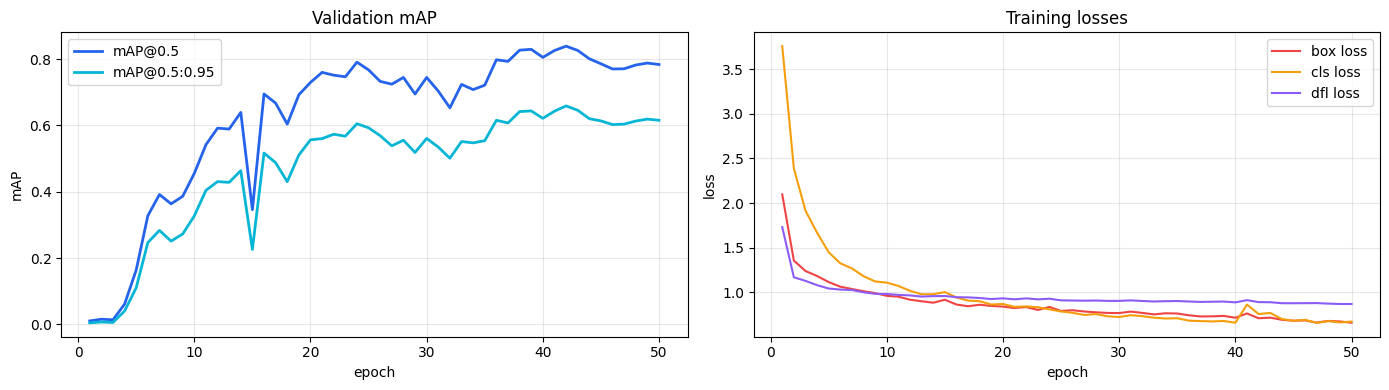

Best epoch: 42 -> mAP50=0.839, precision=0.805, recall=0.800


In [11]:
# 8. Plot the training curves so they're embedded in the notebook output.
import pandas as pd
import matplotlib.pyplot as plt

candidates = sorted(pathlib.Path('runs').glob('**/colab_kaggle_50ep'))
run_dir = next((p for p in candidates if (p / 'results.csv').is_file()), None)
if run_dir is None:
    run_dir = next((p for p in candidates if (p / 'weights' / 'best.pt').is_file()), None)
if run_dir is None:
    raise FileNotFoundError(
        'No run directory containing results.csv or weights/best.pt under runs/. '
        'Did cell 6 finish?  Candidates: ' + str(candidates)
    )
print('using run_dir =', run_dir)
df = pd.read_csv(run_dir / 'results.csv')
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'],     label='mAP@0.5',     color='#2563EB', linewidth=2)
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='#06B6D4', linewidth=2)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('mAP'); axes[0].set_title('Validation mAP')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(df['epoch'], df['train/box_loss'], label='box loss', color='#EF4444')
axes[1].plot(df['epoch'], df['train/cls_loss'], label='cls loss', color='#F59E0B')
axes[1].plot(df['epoch'], df['train/dfl_loss'], label='dfl loss', color='#8B5CF6')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss'); axes[1].set_title('Training losses')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

best = df.loc[df['metrics/mAP50(B)'].idxmax()]
print(f'Best epoch: {int(best.epoch)} -> mAP50={best["metrics/mAP50(B)"]:.3f}, '
      f'precision={best["metrics/precision(B)"]:.3f}, recall={best["metrics/recall(B)"]:.3f}')


In [12]:
# 9. Package best.pt + last.pt + results.csv + confusion matrix into a
#    single zip and trigger a Colab download to your machine.
import shutil
from datetime import datetime

candidates = sorted(pathlib.Path('runs').glob('**/colab_kaggle_50ep'))
run_dir = next((p for p in candidates if (p / 'results.csv').is_file()), None)
if run_dir is None:
    run_dir = next((p for p in candidates if (p / 'weights' / 'best.pt').is_file()), None)
if run_dir is None:
    raise FileNotFoundError(
        'No run directory containing results.csv or weights/best.pt under runs/. '
        'Did cell 6 finish?  Candidates: ' + str(candidates)
    )
print('using run_dir =', run_dir)
stamp = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
bundle = pathlib.Path(f'/content/logivision_colab_run_{stamp}')
bundle.mkdir(exist_ok=True)
for f in ('weights/best.pt', 'weights/last.pt', 'results.csv',
          'confusion_matrix.png', 'confusion_matrix_normalized.png',
          'args.yaml', 'labels.jpg'):
    src = run_dir / f
    if src.is_file():
        shutil.copy(src, bundle / pathlib.Path(f).name)
zip_path = shutil.make_archive(str(bundle), 'zip', bundle)
print(f'bundle: {zip_path} ({pathlib.Path(zip_path).stat().st_size/1e6:.1f} MB)')

# Trigger Colab download (or use right-click in the file panel if this fails)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)


using run_dir = runs/colab_kaggle_50ep


/tmp/ipykernel_10895/3794404707.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  stamp = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


bundle: /content/logivision_colab_run_20260606T180511Z.zip (10.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps on your laptop

After the download completes:

```bash
# 1. Unzip into the repo's ml/runs directory under a colab-named subdir.
RUN_NAME=$(basename ~/Downloads/logivision_colab_run_*.zip .zip)
mkdir -p ml/runs/$RUN_NAME/weights
unzip -o ~/Downloads/${RUN_NAME}.zip -d ml/runs/$RUN_NAME/
mv ml/runs/$RUN_NAME/best.pt ml/runs/$RUN_NAME/weights/best.pt
mv ml/runs/$RUN_NAME/last.pt ml/runs/$RUN_NAME/weights/last.pt

# 2. Register in your local MLflow + promote to Production.
make register-from-colab RUN=$RUN_NAME

# 3. Restart the inference worker so it picks up the new model.
make worker-restart
```

The dashboard's `System` tab will show the new model version + metrics on
next refresh. Detections start using the Colab-trained weights in ~10 s.

## Troubleshooting

| Symptom | Fix |
|---|---|
| `KAGGLE_USERNAME` secret missing | Add it in the Colab sidebar (key icon), toggle Notebook access ON, re-run cell 3 |
| `CUDA out of memory` | Drop `batch=32` to `batch=16` in cell 6 |
| Training stalls at 0 mAP after 5+ epochs | Re-check `data.yaml` — classes/paths must match what cell 5 wrote |
| `files.download()` does nothing | Click the file panel on the left, right-click the zip, "Download" |
